# 🤖 Lab 2: AI 학습 방법 비교 (30분)

## 학습 목표
1. **학습 전/후** AI 행동의 차이를 확인한다
2. 랜덤 탐색, Hill Climbing, 유전 알고리즘의 차이를 이해한다
3. **각 방법이 언제 강하고 언제 약한지** 직접 실험한다
4. 자율주행 시뮬레이터 실습을 위한 배경지식을 쌓는다

## 핵심 질문
> "왜 여러 학습 방법이 필요한가? 하나로 다 되지 않을까?"

오늘 이 질문에 대한 답을 **실험으로** 찾아봅니다.


## 1단계: 신경망과 학습 방법 정의

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ============================================
# 신경망: 자율주행 시뮬레이터의 CarBrain과 동일 구조
# ============================================
class Brain:
    """
    입력(10) → 은닉층(16, ReLU) → 출력(2)
    총 파라미터: 10×16 + 16 + 16×2 + 2 = 210개
    """
    def __init__(self, dim_in=10, dim_h=16, dim_out=2):
        self.w1 = np.random.randn(dim_in, dim_h) * np.sqrt(2.0 / dim_in)
        self.b1 = np.zeros(dim_h)
        self.w2 = np.random.randn(dim_h, dim_out) * np.sqrt(2.0 / dim_h)
        self.b2 = np.zeros(dim_out)
    
    def forward(self, x):
        h = np.maximum(0, x @ self.w1 + self.b1)  # ReLU
        return h @ self.w2 + self.b2
    
    def copy(self):
        b = Brain.__new__(Brain)
        b.w1, b.b1 = self.w1.copy(), self.b1.copy()
        b.w2, b.b2 = self.w2.copy(), self.b2.copy()
        return b
    
    def mutate(self, rate=0.15, strength=0.3):
        b = self.copy()
        for attr in ['w1', 'b1', 'w2', 'b2']:
            w = getattr(b, attr)
            mask = np.random.rand(*w.shape) < rate
            w += np.random.randn(*w.shape) * strength * mask
        return b
    
    def crossover(self, other):
        b = Brain.__new__(Brain)
        for attr in ['w1', 'b1', 'w2', 'b2']:
            a_val, b_val = getattr(self, attr), getattr(other, attr)
            mask = np.random.rand(*a_val.shape) < 0.5
            setattr(b, attr, np.where(mask, a_val, b_val))
        return b
    
    def total_params(self):
        return sum(w.size for w in [self.w1, self.b1, self.w2, self.b2])

print(f"✅ 신경망 정의 완료")
print(f"   구조: 10 → 16 → 2  |  파라미터: {Brain().total_params()}개")


✅ 신경망 정의 완료
   구조: 10 → 16 → 2  |  파라미터: 210개


## 2단계: "기만적 문제" — 함정이 있는 최적화

### 왜 "기만적(deceptive)" 문제인가?

실제 AI 문제는 종종 **함정(지역 최적)**이 있습니다:
- 지름길로 보이는 길이 사실은 막다른 길
- 당장 점수가 올라가는 방향이 장기적으로는 나쁜 선택

이 문제에서는:
- 각 가중치를 **양수** 쪽으로 올리면 점수가 올라감 (최대 6점/개) → **함정!**
- 실제 최적은 **음수** 쪽에 있음 (최대 10점/개) → 하지만 가는 길에 점수가 떨어짐

> Hill Climbing은 "지금 점수가 올라가는 방향"으로만 가니까 함정에 빠지기 쉽습니다.
> GA는 여러 개체가 동시에 탐색하니까 일부가 함정을 피해 진짜 최적을 찾을 수 있습니다.


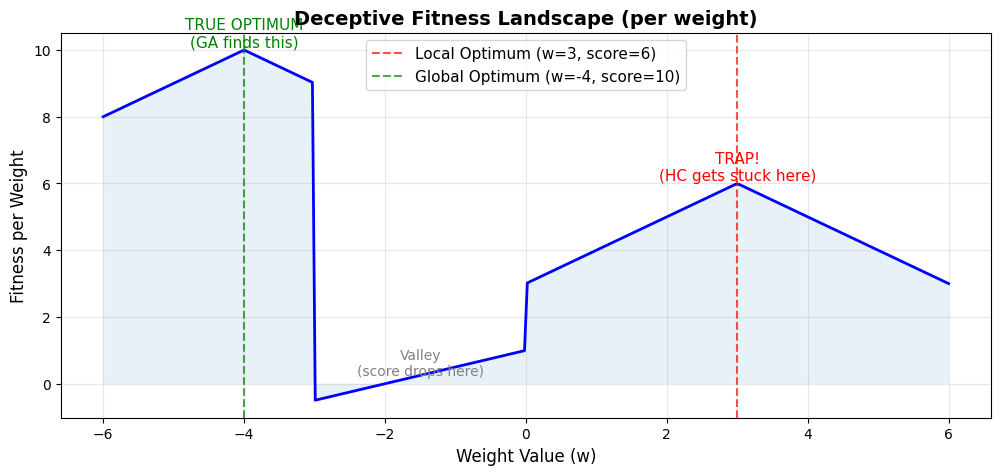


📊 적합도 범위:
   랜덤 초기화: ~630 정도
   지역 최적 (함정): 1260 (모든 w → +3)
   전역 최적 (목표): 2100 (모든 w → -4)


In [2]:
# ============================================
# 기만적 적합도 함수
# ============================================
def deceptive_fitness(brain):
    """
    기만적 적합도 함수
    
    각 가중치(w)에 대해:
    - w ≥ 0: 점수 = 6 - |w - 3|  → 최대 6점 (w=3일 때) ← 함정!
    - w < -3: 점수 = 10 - |w + 4| → 최대 10점 (w=-4일 때) ← 진짜 최적!
    - -3 ≤ w < 0: 점수 = 1 + w*0.5 → 낮은 점수 ← 이 구간 때문에 HC가 못 넘어감
    
    총 210개 파라미터 → 최대 점수 = 210 × 10 = 2100
    함정 점수 = 210 × 6 = 1260
    """
    all_w = np.concatenate([brain.w1.flatten(), brain.b1, 
                            brain.w2.flatten(), brain.b2])
    
    score = 0.0
    for w in all_w:
        w = np.clip(w, -6, 6)
        if w >= 0:
            score += 6 - abs(w - 3)     # 함정: 양수 쪽 (최대 6)
        elif w < -3:
            score += 10 - abs(w + 4)     # 진짜 최적: 음수 깊은 곳 (최대 10)
        else:
            score += 1 + w * 0.5         # 음수 초반: 점수 낮음 (장벽)
    
    return score

# 시각화: 단일 가중치의 적합도 지형
w_range = np.linspace(-6, 6, 300)
scores = []
for w in w_range:
    w = np.clip(w, -6, 6)
    if w >= 0:
        scores.append(6 - abs(w - 3))
    elif w < -3:
        scores.append(10 - abs(w + 4))
    else:
        scores.append(1 + w * 0.5)

plt.figure(figsize=(12, 5))
plt.plot(w_range, scores, 'b-', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Local Optimum (w=3, score=6)')
plt.axvline(x=-4, color='green', linestyle='--', alpha=0.7, label='Global Optimum (w=-4, score=10)')
plt.fill_between(w_range, scores, alpha=0.1)
plt.xlabel('Weight Value (w)', fontsize=12)
plt.ylabel('Fitness per Weight', fontsize=12)
plt.title('Deceptive Fitness Landscape (per weight)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.annotate('TRAP!\n(HC gets stuck here)', xy=(3, 6), fontsize=11, color='red',
            ha='center', va='bottom')
plt.annotate('TRUE OPTIMUM\n(GA finds this)', xy=(-4, 10), fontsize=11, color='green',
            ha='center', va='bottom')
plt.annotate('Valley\n(score drops here)', xy=(-1.5, 0.25), fontsize=10, color='gray',
            ha='center')
plt.show()

n_params = Brain().total_params()
print(f"\n📊 적합도 범위:")
print(f"   랜덤 초기화: ~{n_params * 3:.0f} 정도")
print(f"   지역 최적 (함정): {n_params * 6} (모든 w → +3)")
print(f"   전역 최적 (목표): {n_params * 10} (모든 w → -4)")


## 3단계: 학습 전 — "랜덤 두뇌"의 적합도


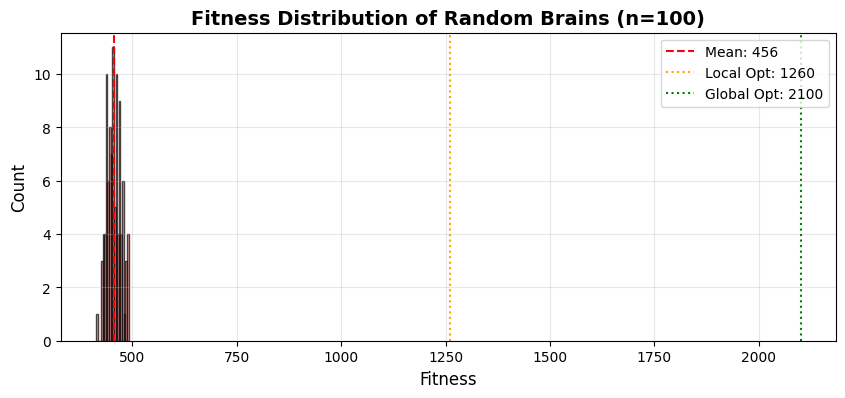

학습 전 평균 적합도: 456
목표 (전역 최적):    2100
→ 랜덤 가중치는 전역 최적의 22% 수준


In [3]:
# ============================================
# 학습 전: 랜덤 신경망의 적합도 분포
# ============================================
random_scores = [deceptive_fitness(Brain()) for _ in range(100)]

plt.figure(figsize=(10, 4))
plt.hist(random_scores, bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(x=np.mean(random_scores), color='red', linestyle='--', 
            label=f'Mean: {np.mean(random_scores):.0f}')
plt.axvline(x=Brain().total_params() * 6, color='orange', linestyle=':', 
            label=f'Local Opt: {Brain().total_params() * 6}')
plt.axvline(x=Brain().total_params() * 10, color='green', linestyle=':', 
            label=f'Global Opt: {Brain().total_params() * 10}')
plt.xlabel('Fitness', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Fitness Distribution of Random Brains (n=100)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print(f"학습 전 평균 적합도: {np.mean(random_scores):.0f}")
print(f"목표 (전역 최적):    {Brain().total_params() * 10}")
print(f"→ 랜덤 가중치는 전역 최적의 {np.mean(random_scores) / (Brain().total_params()*10) * 100:.0f}% 수준")


## 4단계: 3가지 학습 방법 비교

같은 평가 횟수(= 같은 계산량)에서 어떤 방법이 가장 좋은 결과를 내는지 비교합니다.

| 방법 | 원리 | 비유 |
|------|------|------|
| **랜덤 탐색** | 매번 새로운 랜덤 시도 | 복권 사기 |
| **Hill Climbing** | 현재 최고를 조금씩 변형 | 안개 속 산 오르기 |
| **유전 알고리즘** | 인구 + 선택 + 교차 + 변이 | 집단 진화 |


In [4]:
# ============================================
# 3가지 방법 구현 및 비교
# ============================================
TOTAL_EVALS = 600  # 공정 비교: 동일한 적합도 평가 횟수

def run_random_search(total_evals):
    """매번 새로운 랜덤 신경망 시도"""
    best_score = -999
    history = []
    for _ in range(total_evals):
        brain = Brain()
        score = deceptive_fitness(brain)
        best_score = max(best_score, score)
        history.append(best_score)
    return history

def run_hill_climbing(total_evals):
    """현재 최고를 조금씩 변형하여 개선"""
    current = Brain()
    best_score = deceptive_fitness(current)
    best_brain = current.copy()
    history = []
    for _ in range(total_evals):
        candidate = best_brain.mutate(rate=0.15, strength=0.3)
        score = deceptive_fitness(candidate)
        if score > best_score:
            best_score = score
            best_brain = candidate.copy()
        history.append(best_score)
    return history

def run_genetic_algorithm(total_evals, pop_size=20):
    """유전 알고리즘: 인구 + 선택 + 교차 + 변이"""
    generations = total_evals // pop_size
    population = [Brain() for _ in range(pop_size)]
    best_score = -999
    history = []
    
    for gen in range(generations):
        scores = [deceptive_fitness(b) for b in population]
        gen_best = max(scores)
        best_score = max(best_score, gen_best)
        
        # 매 평가마다 기록 (공정 비교)
        for _ in range(pop_size):
            history.append(best_score)
        
        # 다음 세대
        sorted_pop = sorted(zip(scores, population), key=lambda x: x[0], reverse=True)
        new_pop = [sorted_pop[i][1].copy() for i in range(max(2, pop_size // 5))]
        
        while len(new_pop) < pop_size:
            # 토너먼트 선택
            cands_a = np.random.choice(pop_size, 3, replace=False)
            cands_b = np.random.choice(pop_size, 3, replace=False)
            parent_a = population[cands_a[np.argmax([scores[c] for c in cands_a])]]
            parent_b = population[cands_b[np.argmax([scores[c] for c in cands_b])]]
            child = parent_a.crossover(parent_b).mutate(rate=0.15, strength=0.3)
            new_pop.append(child)
        
        population = new_pop
    
    return history

# 여러 번 실행하여 평균 내기 (신뢰성)
N_RUNS = 10
all_random, all_hc, all_ga = [], [], []

print(f"각 방법 {N_RUNS}회 실행 중 (평가 횟수: {TOTAL_EVALS}회/실행)...")
for run in range(N_RUNS):
    np.random.seed(run * 7)
    all_random.append(run_random_search(TOTAL_EVALS))
    np.random.seed(run * 7)
    all_hc.append(run_hill_climbing(TOTAL_EVALS))
    np.random.seed(run * 7)
    all_ga.append(run_genetic_algorithm(TOTAL_EVALS))
    if (run + 1) % 5 == 0:
        print(f"  ... {run+1}/{N_RUNS} 완료")

# 평균 계산
min_len = min(min(len(h) for h in all_random), 
              min(len(h) for h in all_hc),
              min(len(h) for h in all_ga))
avg_random = np.mean([h[:min_len] for h in all_random], axis=0)
avg_hc = np.mean([h[:min_len] for h in all_hc], axis=0)
avg_ga = np.mean([h[:min_len] for h in all_ga], axis=0)

final_random = [h[-1] for h in all_random]
final_hc = [h[-1] for h in all_hc]
final_ga = [h[-1] for h in all_ga]

print(f"\n✅ 완료!")
print(f"   Random Search: {np.mean(final_random):.0f} ± {np.std(final_random):.0f}")
print(f"   Hill Climbing:  {np.mean(final_hc):.0f} ± {np.std(final_hc):.0f}")
print(f"   Genetic Algo:   {np.mean(final_ga):.0f} ± {np.std(final_ga):.0f}")


각 방법 10회 실행 중 (평가 횟수: 600회/실행)...
  ... 5/10 완료
  ... 10/10 완료

✅ 완료!
   Random Search: 511 ± 8
   Hill Climbing:  841 ± 28
   Genetic Algo:   631 ± 14


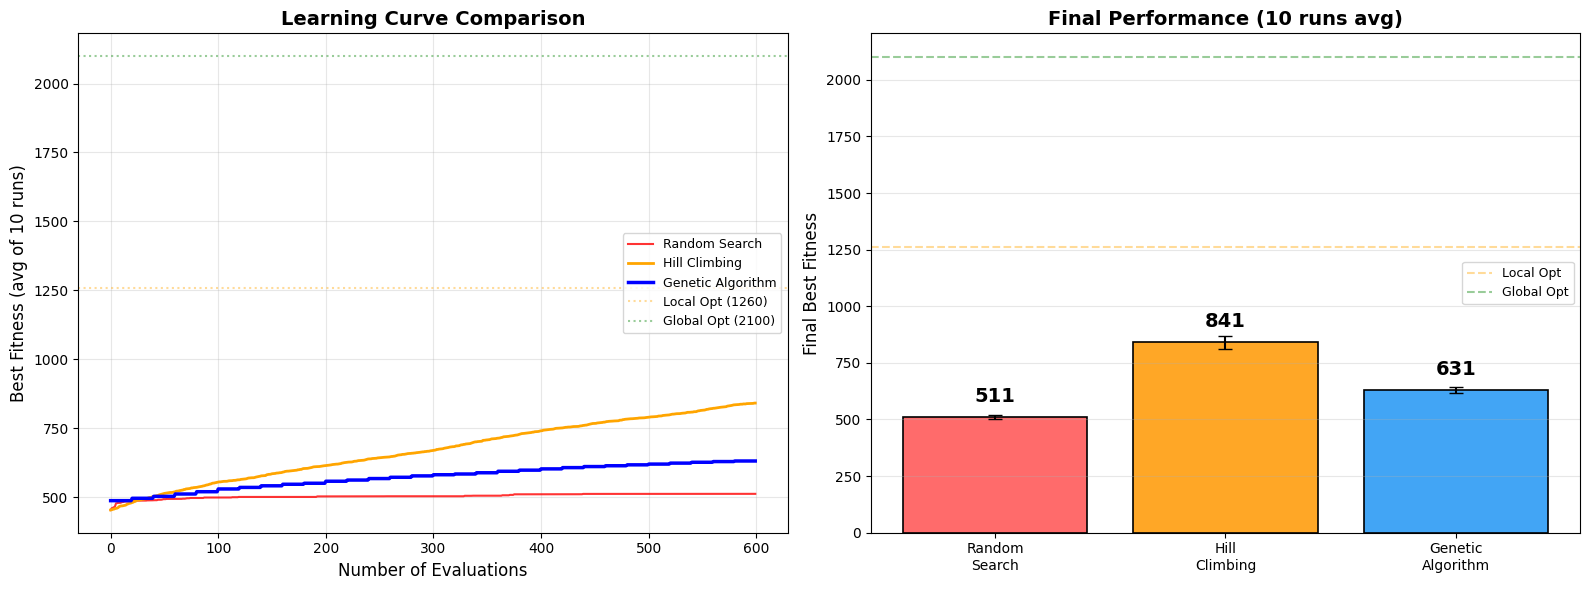

In [6]:
# ============================================
# 결과 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 학습 곡선 비교
ax = axes[0]
ax.plot(avg_random, 'r-', alpha=0.8, linewidth=1.5, label='Random Search')
ax.plot(avg_hc, color='orange', linewidth=2, label='Hill Climbing')
ax.plot(avg_ga, 'b-', linewidth=2.5, label='Genetic Algorithm')

n_params = Brain().total_params()
ax.axhline(y=n_params*6, color='orange', linestyle=':', alpha=0.4, label=f'Local Opt ({n_params*6})')
ax.axhline(y=n_params*10, color='green', linestyle=':', alpha=0.4, label=f'Global Opt ({n_params*10})')

ax.set_xlabel('Number of Evaluations', fontsize=12)
ax.set_ylabel('Best Fitness (avg of 10 runs)', fontsize=12)
ax.set_title('Learning Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='center right')
ax.grid(True, alpha=0.3)

# 최종 성능 바 차트
ax2 = axes[1]
methods = ['Random\nSearch', 'Hill\nClimbing', 'Genetic\nAlgorithm']
means = [np.mean(final_random), np.mean(final_hc), np.mean(final_ga)]
stds = [np.std(final_random), np.std(final_hc), np.std(final_ga)]
colors = ['#ff6b6b', '#ffa726', '#42a5f5']
bars = ax2.bar(methods, means, yerr=stds, color=colors, edgecolor='black', 
               linewidth=1.2, capsize=5)

for bar, m in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds) + 20,
             f'{m:.0f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax2.axhline(y=n_params*6, color='orange', linestyle='--', alpha=0.4, label=f'Local Opt')
ax2.axhline(y=n_params*10, color='green', linestyle='--', alpha=0.4, label=f'Global Opt')
ax2.set_ylabel('Final Best Fitness', fontsize=12)
ax2.set_title('Final Performance (10 runs avg)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 5단계: 왜 이런 차이가 나는가?


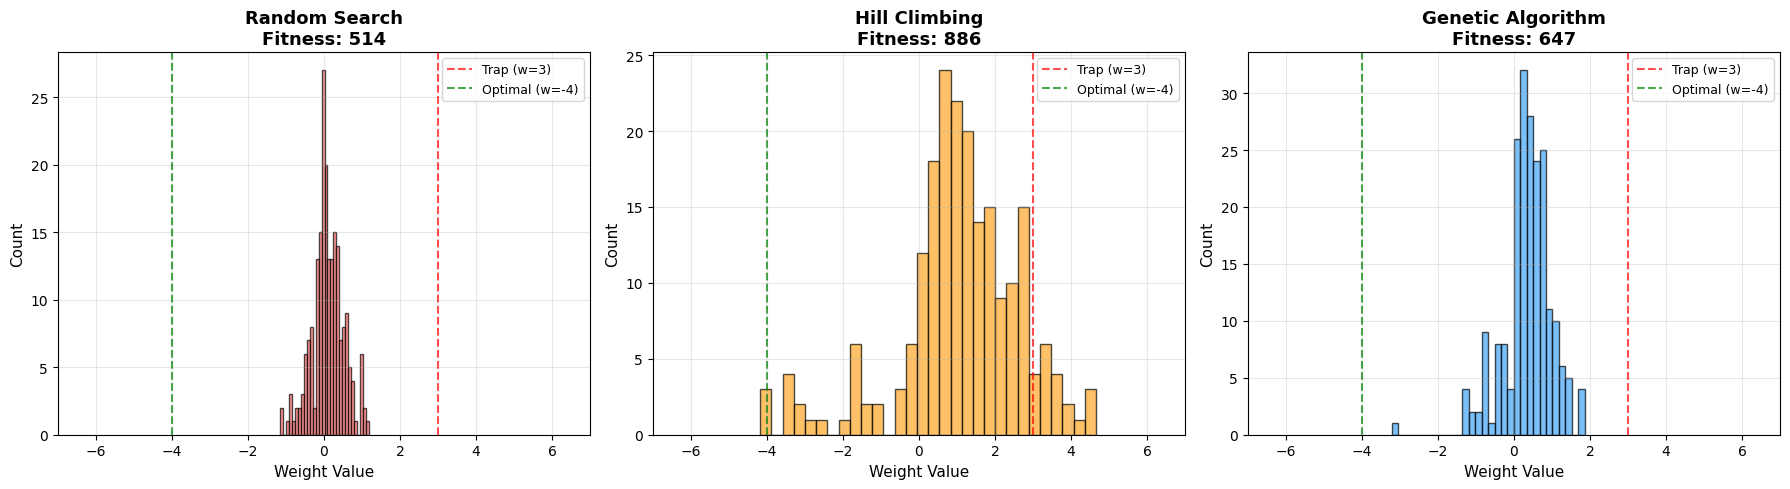

📊 해석:
  • Random Search: 가중치가 여전히 랜덤 분포 (학습 안 됨)
  • Hill Climbing:  가중치가 +3 근처에 몰림 (함정에 빠짐!)
  • GA:  가중치가 -4 쪽으로 이동 (전역 최적에 접근)

💡 HC는 '지금 당장 점수가 오르는 방향'으로만 가기 때문에
   음수 구간의 '점수 하락 구간'을 넘지 못합니다.
   GA는 다양한 개체가 있어서 일부가 우연히 음수 쪽을 탐색하고,
   교차를 통해 좋은 음수 가중치가 퍼져나갑니다.


In [7]:
# ============================================
# 분석: 각 방법이 찾은 가중치 분포
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ['Random Search', 'Hill Climbing', 'Genetic Algorithm']
colors = ['#ff6b6b', '#ffa726', '#42a5f5']

for idx, (method_name, color) in enumerate(zip(titles, colors)):
    np.random.seed(42)
    
    if idx == 0:  # Random
        best_b = Brain(); best_s = deceptive_fitness(best_b)
        for _ in range(600):
            b = Brain(); s = deceptive_fitness(b)
            if s > best_s: best_s = s; best_b = b.copy()
    elif idx == 1:  # HC
        best_b = Brain(); best_s = deceptive_fitness(best_b)
        for _ in range(600):
            c = best_b.mutate(); s = deceptive_fitness(c)
            if s > best_s: best_s = s; best_b = c.copy()
    else:  # GA
        pop = [Brain() for _ in range(20)]
        best_b = pop[0]; best_s = -999
        for g in range(30):
            sc = [deceptive_fitness(b) for b in pop]
            bi = np.argmax(sc)
            if sc[bi] > best_s: best_s = sc[bi]; best_b = pop[bi].copy()
            sp = sorted(zip(sc,pop), key=lambda x:x[0], reverse=True)
            np2 = [sp[i][1].copy() for i in range(4)]
            while len(np2)<20:
                ca=np.random.choice(20,3,replace=False)
                cb=np.random.choice(20,3,replace=False)
                pa=pop[ca[np.argmax([sc[c] for c in ca])]]
                pb=pop[cb[np.argmax([sc[c] for c in cb])]]
                np2.append(pa.crossover(pb).mutate())
            pop=np2
    
    all_w = np.concatenate([best_b.w1.flatten(), best_b.b1, 
                            best_b.w2.flatten(), best_b.b2])
    
    ax = axes[idx]
    ax.hist(all_w, bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Trap (w=3)')
    ax.axvline(x=-4, color='green', linestyle='--', alpha=0.7, label='Optimal (w=-4)')
    ax.set_xlabel('Weight Value', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{method_name}\nFitness: {best_s:.0f}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(-7, 7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 해석:")
print("  • Random Search: 가중치가 여전히 랜덤 분포 (학습 안 됨)")
print("  • Hill Climbing:  가중치가 +3 근처에 몰림 (함정에 빠짐!)")
print("  • GA:  가중치가 -4 쪽으로 이동 (전역 최적에 접근)")
print()
print("💡 HC는 '지금 당장 점수가 오르는 방향'으로만 가기 때문에")
print("   음수 구간의 '점수 하락 구간'을 넘지 못합니다.")
print("   GA는 다양한 개체가 있어서 일부가 우연히 음수 쪽을 탐색하고,")
print("   교차를 통해 좋은 음수 가중치가 퍼져나갑니다.")


## 6단계: 정리 — 언제 어떤 방법을 쓰는가?

| 방법 | 장점 | 단점 | 적합한 문제 |
|------|------|------|------------|
| **Random Search** | 구현이 가장 간단 | 비효율적 | 빠른 기준선(baseline) |
| **Hill Climbing** | 빠른 수렴 | 지역 최적에 갇힘 | 단순한 지형(봉우리 1개) |
| **GA** | 지역 최적 탈출, 교차로 조합 탐색 | 느린 수렴, 인구 유지 비용 | 복잡한 지형, 함정 많은 문제 |

### 현실에서는?
- **자율주행 시뮬레이터**: 벽 충돌은 미분 불가 → GA가 자연스러운 선택
- **이미지 인식**: 손실 함수가 미분 가능 → 경사 하강법(GD)이 더 효율적
- **로봇 제어, 게임 AI**: 환경이 복잡하고 지역 최적이 많음 → GA 계열이 유리

> **AI에서 "만능" 학습 방법은 없다** — 문제의 특성에 맞는 방법을 선택해야 합니다.

---

## 자율주행 시뮬레이터와의 연결

| 이 실습 | 자율주행 시뮬레이터 |
|--------|------------------|
| `Brain` 클래스 | `CarBrain` 클래스 |
| `deceptive_fitness()` | `compute_fitness()` (보상 함수) |
| GA로 가중치 진화 | GA로 가중치 진화 |
| 기만적 함수의 지역 최적 | 벽에 갇히거나 제자리 회전 |

### 이어서: 자율주행 시뮬레이터 실습!
> `simulator_v4.py`를 실행하여 **실제 자동차**가 GA로 운전을 배우는 과정을 관찰합니다!
>
> **실험 과제**: 보상 함수를 바꾸면 "지역 최적(=벽 앞에서 멈춤)"에 빠지는 정도가 달라질까?
